In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import plotly.express as px
import numpy as np
#import plotly.graph_objects as go
from statsmodels.stats.weightstats import ztest


df1 = pd.read_csv('C:\Personal\Masters\Masters_work\Study\Y1_S1\HIT140\Assessment_2\HIT_140_Assessment_2_200925\HIT_140_assessment_2\Datasets\cleaned_dataset1.csv')
df2 = pd.read_csv('C:\Personal\Masters\Masters_work\Study\Y1_S1\HIT140\Assessment_2\HIT_140_Assessment_2_200925\HIT_140_assessment_2\Datasets\dataset2_cleaned_V2.csv')

df2.info()
df2.describe()
df2.head()

# Now we are going to see the number of rows and columns in the dataset
print(f"Dataset 2 dimensions: ") 
print(f"Number of rows: {df2.shape[0]}") 
print(f"Number of columns: {df2.shape[1]}")


# Splitting the DataFrame based on the column 'B'
df2_0 = df2[(df2['month'] == 0)]
df2_1 = df2[(df2['month'] == 1)]
df2_2 = df2[(df2['month'] == 2)]
df2_3 = df2[(df2['month'] == 3)]
df2_4 = df2[(df2['month'] == 4)]
df2_5 = df2[(df2['month'] == 5)]
df2_6 = df2[(df2['month'] == 6)]


lengths = {
    '0': len(df2_0),
    '1': len(df2_1),
    '2': len(df2_2),
    '3': len(df2_3),
    '4': len(df2_4),
    '5': len(df2_5),
    '6': len(df2_6)

}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1897 entries, 0 to 1896
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                1897 non-null   object 
 1   month               1897 non-null   int64  
 2   hours_after_sunset  1897 non-null   float64
 3   bat_landing_number  1897 non-null   int64  
 4   food_availability   1897 non-null   float64
 5   rat_minutes         1897 non-null   float64
 6   rat_arrival_number  1897 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 103.9+ KB
Dataset 2 dimensions: 
Number of rows: 1897
Number of columns: 7


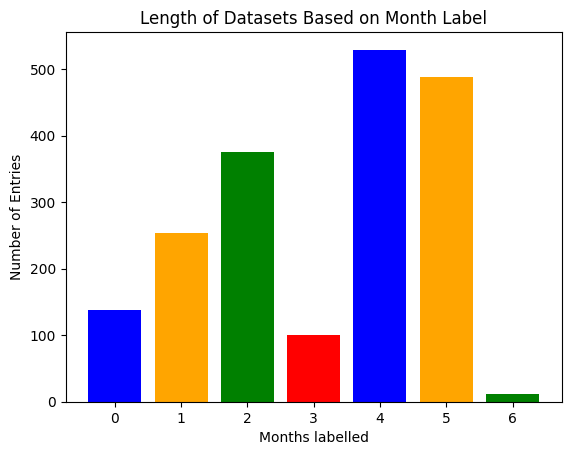

In [ ]:
# Plotting the lengths

plt.bar(lengths.keys(), lengths.values(), color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Months labelled')
plt.ylabel('Number of Entries')
plt.title('Length of Datasets Based on Month Label')
plt.show()

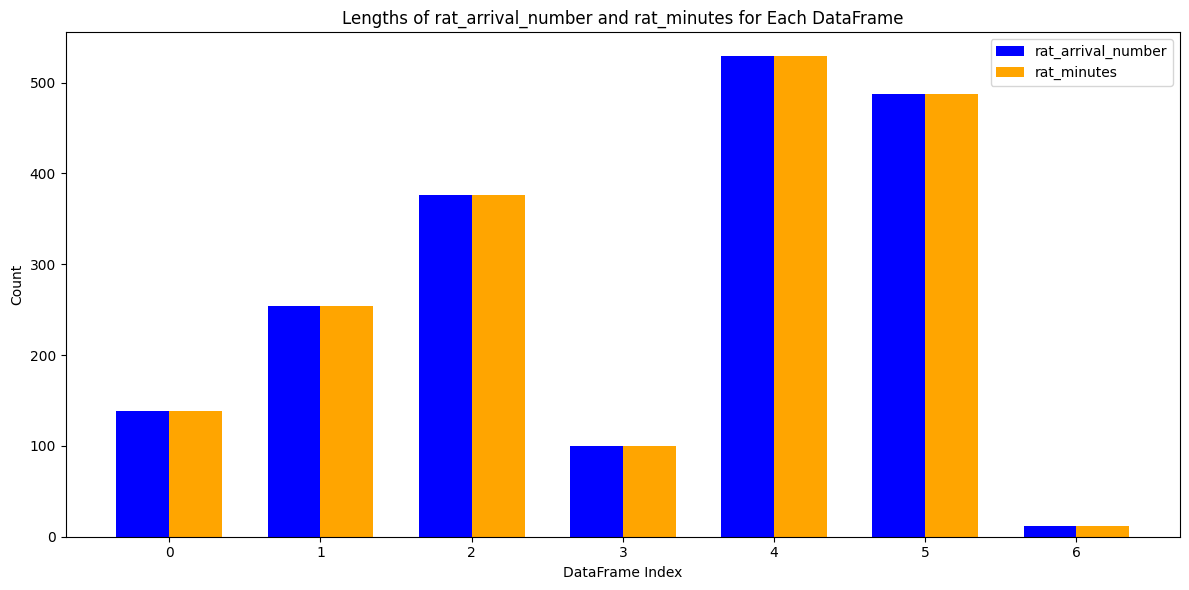

In [ ]:
dataset_split_parameter = ['rat_arrival_number', 'rat_minutes']
test_column = ['bat_landing_number', 'food_availability','hours_after_sunset']

#

# List of DataFrames
dataframes = [df2_0, df2_1, df2_2, df2_3, df2_4, df2_5, df2_6]
labels = ['0', '1', '2', '3', '4', '5', '6']

# Prepare data for plotting
rat_arrival_lengths = []
rat_minutes_lengths = []

for df in dataframes:
    rat_arrival_lengths.append(len(df['rat_arrival_number']) if 'rat_arrival_number' in df.columns else 0)
    rat_minutes_lengths.append(len(df['rat_minutes']) if 'rat_minutes' in df.columns else 0)

# Plotting
x = range(len(labels))  # X-axis positions

plt.figure(figsize=(12, 6))

# Bar width
bar_width = 0.35

# Create bars for 'rat_arrival_number'
plt.bar(x, rat_arrival_lengths, width=bar_width, label='rat_arrival_number', color='blue', align='center')

# Create bars for 'rat_minutes', shifted to the right
plt.bar([p + bar_width for p in x], rat_minutes_lengths, width=bar_width, label='rat_minutes', color='orange', align='center')

# Adding labels and title
plt.xlabel('DataFrame Index')
plt.ylabel('Count')
plt.title('Lengths of rat_arrival_number and rat_minutes for Each DataFrame')
plt.xticks([p + bar_width / 2 for p in x], labels)  # Center the x-ticks
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

<ipython-input-4-aebcb5779506>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-4-aebcb5779506>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-4-aebcb5779506>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

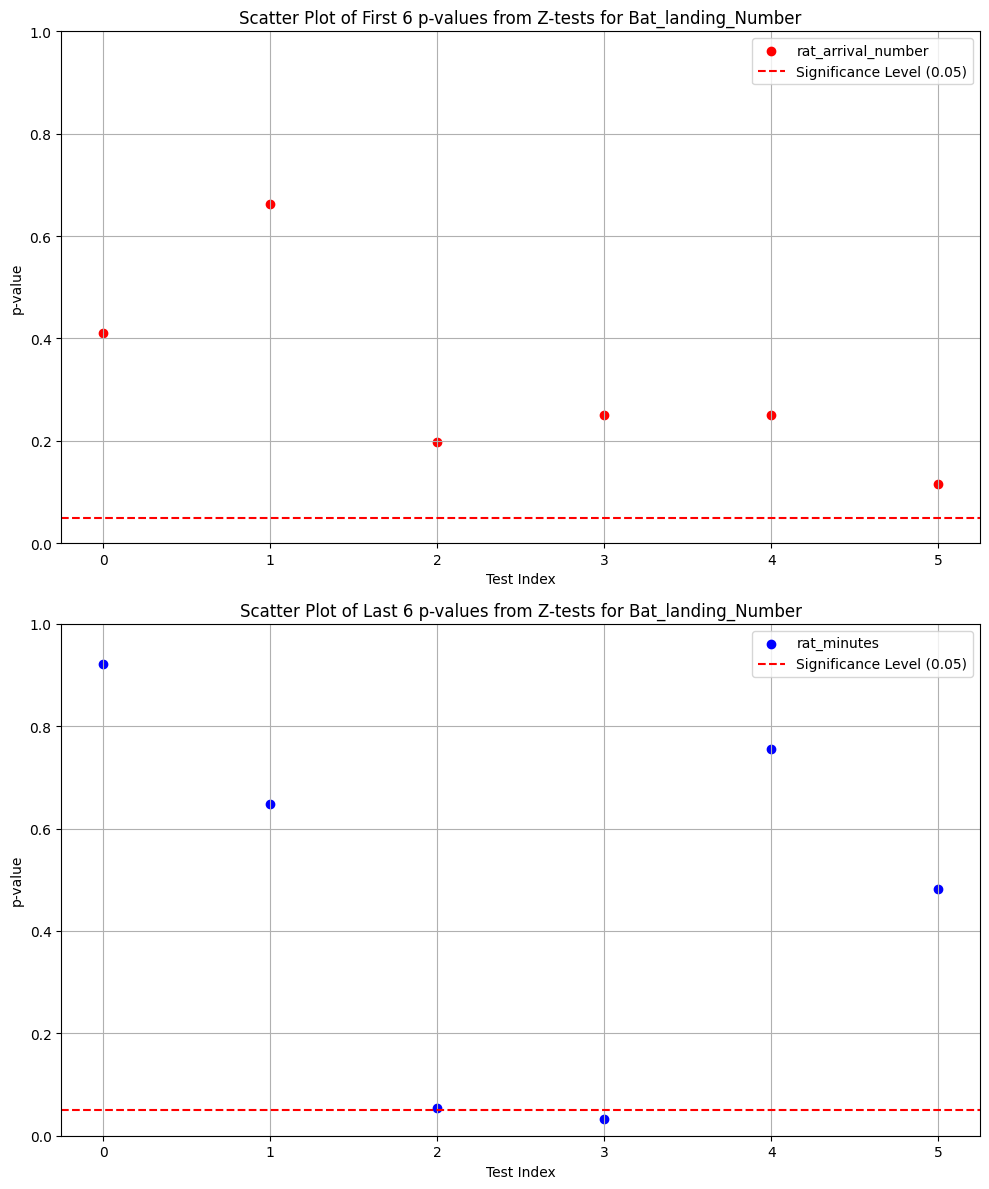

In [ ]:
# List of DataFrames
dataframes = [df2_0, df2_1, df2_2, df2_3, df2_4, df2_5]
dataset_split_parameter = ['rat_arrival_number', 'rat_minutes']
test_column = ['bat_landing_number']
               
               #, 'food_availability','hours_after_sunset']
# Loop through each DataFrame
# Loop through each DataFrame
# Initialize an empty list to store p-values
p_values = []

# Loop through each DataFrame
for df in dataframes:
    for x in dataset_split_parameter:
        for y in test_column:
            # Converts the x column to integers
            df[x] = df[x].astype(int)

            # Creates two dataframes as per the two sections
            df_above_zero = df[df[x] > 0]
            df_zero = df[df[x] == 0]

            # Perform Z-test if both groups have samples
            if len(df_above_zero) > 0 and len(df_zero) > 0:
                z_stats, p_val = ztest(df_above_zero[y], df_zero[y], alternative='two-sided')

                # Append the p-value to the list
                p_values.append(p_val)

                # Determine whether to accept or reject the null hypothesis
                conclusion = "We reject the null hypothesis." if p_val < 0.05 else "We accept the null hypothesis."

                # Print Z-test statistic, p-value, and conclusion
                # print(f"Z-statistic: {z_stats:.2f}, p-value: {p_val:.10f}, Conclusion: {conclusion}")

# Optionally, print the list of p-values after the loop
# print("\nList of p-values:", p_values)
                
# Assuming p_values contains at least 12 values
# Example p_values for demonstration
# p_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12]

# plt.figure(figsize=(10, 6))

# # Plot the first 6 p-values in red
# plt.scatter(range(6), p_values[:6], color='red', marker='o', label='rat_arrival_number')

# # Plot the last 6 p-values in blue
# plt.scatter(range(6, 12), p_values[6:12], color='blue', marker='o', label='rat_minutes')

# # Add a horizontal line for the significance level
# plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')

# # Title and labels
# plt.title('Scatter Plot of p-values from Z-tests')
# plt.xlabel('Test Index')
# plt.ylabel('p-value')
# plt.xticks(range(12))  # Set x-ticks to match the number of p-values
# plt.ylim(0, 1)  # Set y-axis limits
# plt.legend()
# plt.grid()
# plt.show()

# Create a figure with two subplots
plt.figure(figsize=(10, 12))

# First subplot for the first 6 p-values
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(range(6), p_values[:6], color='red', marker='o', label='rat_arrival_number')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of First 6 p-values from Z-tests for Bat_landing_Number')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Second subplot for the last 6 p-values
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.scatter(range(6), p_values[6:12], color='blue', marker='o', label='rat_minutes')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of Last 6 p-values from Z-tests for Bat_landing_Number')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

<ipython-input-5-779a341f6d0f>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-5-779a341f6d0f>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-5-779a341f6d0f>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

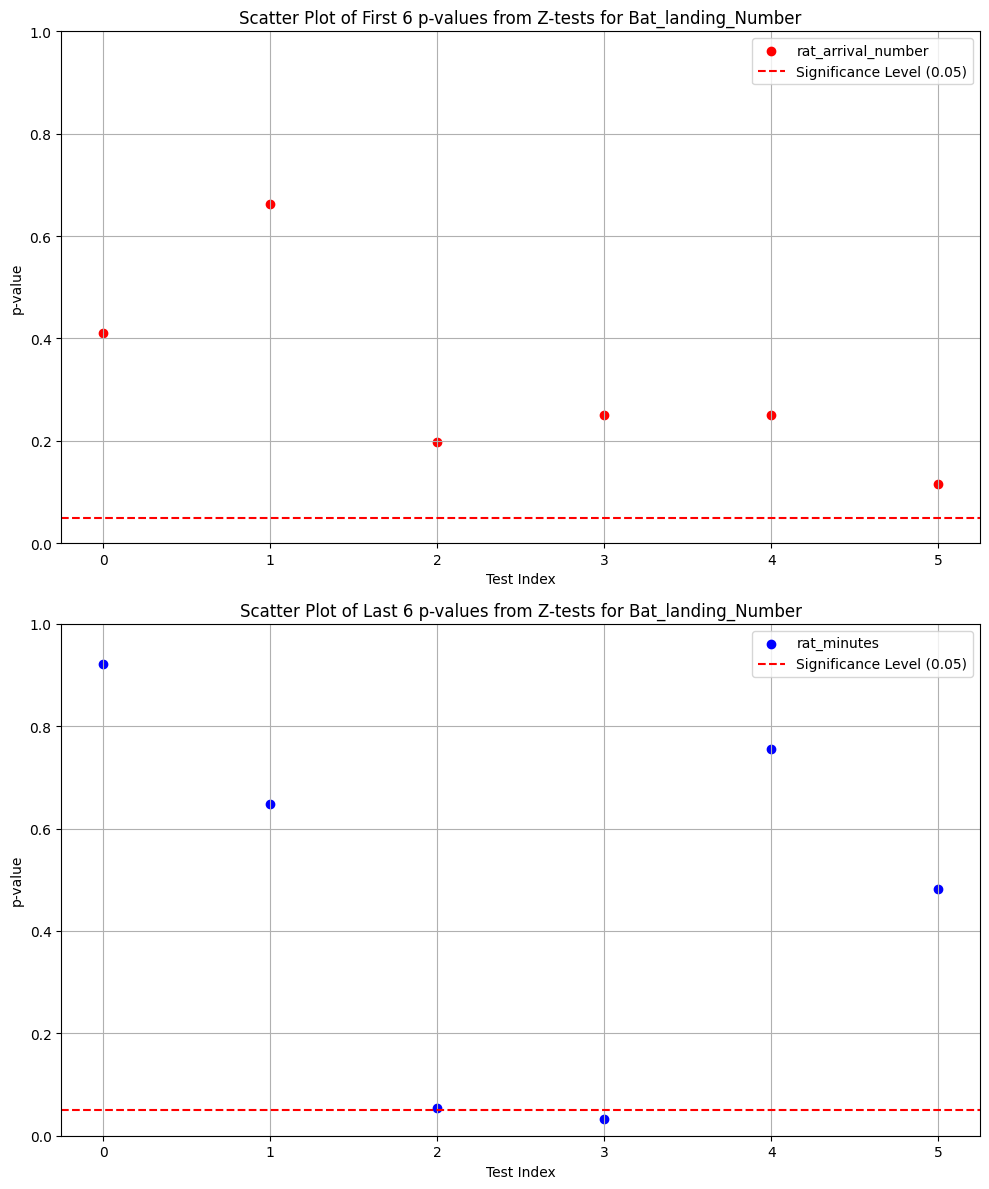

In [ ]:
dataframes = [df2_0, df2_1, df2_2, df2_3, df2_4, df2_5]
dataset_split_parameter = ['rat_arrival_number', 'rat_minutes']
test_column = ['bat_landing_number']
               
               #, 'food_availability','hours_after_sunset']
# Loop through each DataFrame
# Loop through each DataFrame
# Initialize an empty list to store p-values
p_values = []

# Loop through each DataFrame
for df in dataframes:
    for x in dataset_split_parameter:
        for y in test_column:
            # Converts the x column to integers
            df[x] = df[x].astype(int)

            # Creates two dataframes as per the two sections
            df_above_zero = df[df[x] > 0]
            df_zero = df[df[x] == 0]

            # Perform Z-test if both groups have samples
            if len(df_above_zero) > 0 and len(df_zero) > 0:
                z_stats, p_val = ztest(df_above_zero[y], df_zero[y], alternative='two-sided')

                # Append the p-value to the list
                p_values.append(p_val)

                # Determine whether to accept or reject the null hypothesis
                conclusion = "We reject the null hypothesis." if p_val < 0.05 else "We accept the null hypothesis."

                # Print Z-test statistic, p-value, and conclusion
                # print(f"Z-statistic: {z_stats:.2f}, p-value: {p_val:.10f}, Conclusion: {conclusion}")

# Optionally, print the list of p-values after the loop
# print("\nList of p-values:", p_values)
                
# Assuming p_values contains at least 12 values
# Example p_values for demonstration
# p_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12]

# plt.figure(figsize=(10, 6))

# # Plot the first 6 p-values in red
# plt.scatter(range(6), p_values[:6], color='red', marker='o', label='rat_arrival_number')

# # Plot the last 6 p-values in blue
# plt.scatter(range(6, 12), p_values[6:12], color='blue', marker='o', label='rat_minutes')

# # Add a horizontal line for the significance level
# plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')

# # Title and labels
# plt.title('Scatter Plot of p-values from Z-tests')
# plt.xlabel('Test Index')
# plt.ylabel('p-value')
# plt.xticks(range(12))  # Set x-ticks to match the number of p-values
# plt.ylim(0, 1)  # Set y-axis limits
# plt.legend()
# plt.grid()
# plt.show()

# Create a figure with two subplots
plt.figure(figsize=(10, 12))

# First subplot for the first 6 p-values
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(range(6), p_values[:6], color='red', marker='o', label='rat_arrival_number')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of First 6 p-values from Z-tests for Bat_landing_Number')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Second subplot for the last 6 p-values
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.scatter(range(6), p_values[6:12], color='blue', marker='o', label='rat_minutes')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of Last 6 p-values from Z-tests for Bat_landing_Number')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

<ipython-input-6-aefc18ff32a4>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-6-aefc18ff32a4>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-6-aefc18ff32a4>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

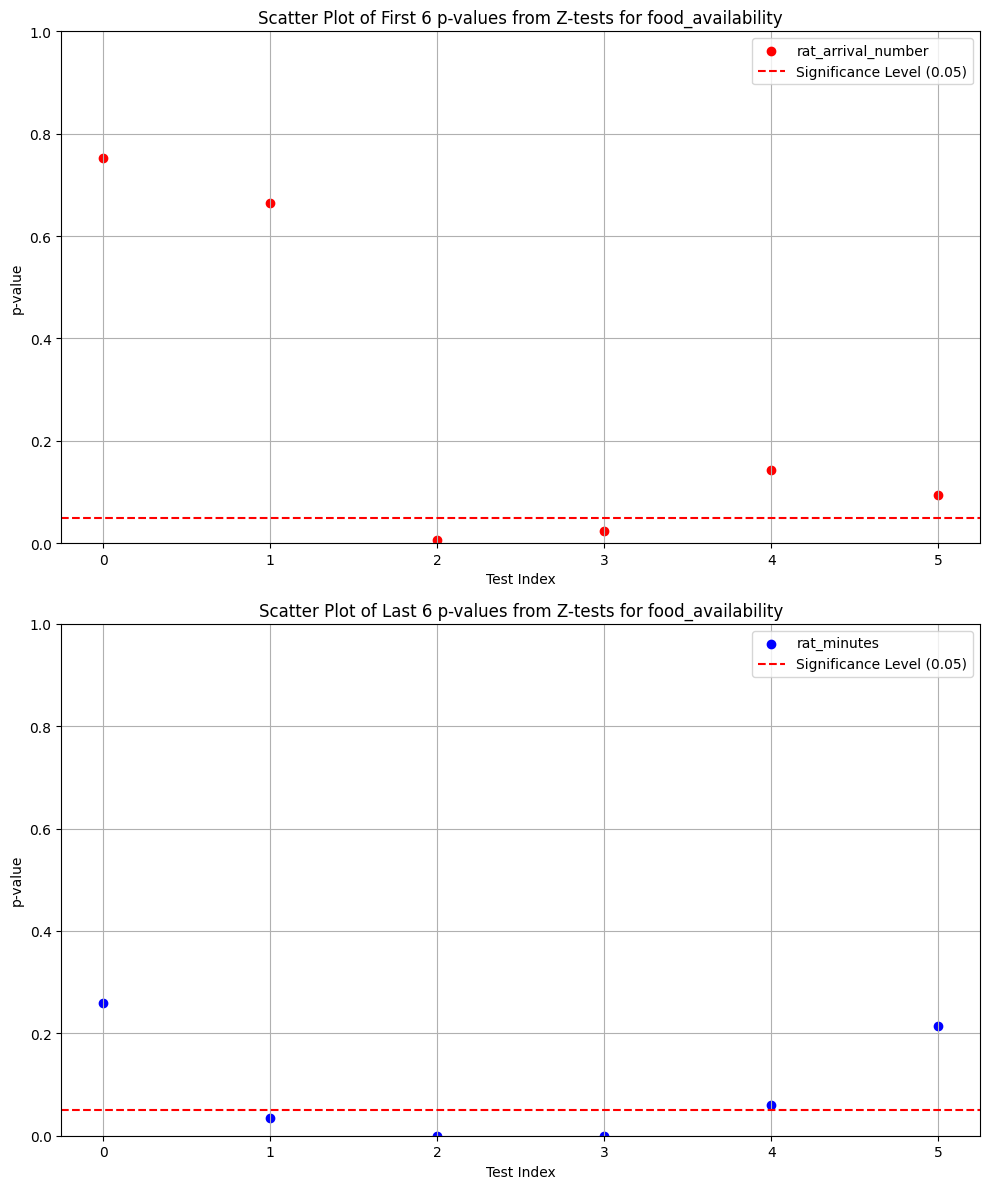

In [ ]:
dataframes = [df2_0, df2_1, df2_2, df2_3, df2_4, df2_5]
dataset_split_parameter = ['rat_arrival_number', 'rat_minutes']
test_column = ['food_availability']
               
               #, 'food_availability','hours_after_sunset']
# Loop through each DataFrame
# Loop through each DataFrame
# Initialize an empty list to store p-values
p_values = []

# Loop through each DataFrame
for df in dataframes:
    for x in dataset_split_parameter:
        for y in test_column:
            # Converts the x column to integers
            df[x] = df[x].astype(int)

            # Creates two dataframes as per the two sections
            df_above_zero = df[df[x] > 0]
            df_zero = df[df[x] == 0]

            # Perform Z-test if both groups have samples
            if len(df_above_zero) > 0 and len(df_zero) > 0:
                z_stats, p_val = ztest(df_above_zero[y], df_zero[y], alternative='two-sided')

                # Append the p-value to the list
                p_values.append(p_val)

                # Determine whether to accept or reject the null hypothesis
                conclusion = "We reject the null hypothesis." if p_val < 0.05 else "We accept the null hypothesis."


plt.figure(figsize=(10, 12))

# First subplot for the first 6 p-values
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(range(6), p_values[:6], color='red', marker='o', label='rat_arrival_number')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of First 6 p-values from Z-tests for food_availability')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Second subplot for the last 6 p-values
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.scatter(range(6), p_values[6:12], color='blue', marker='o', label='rat_minutes')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of Last 6 p-values from Z-tests for food_availability')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

<ipython-input-7-62acbafc9c86>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-7-62acbafc9c86>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].astype(int)
<ipython-input-7-62acbafc9c86>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

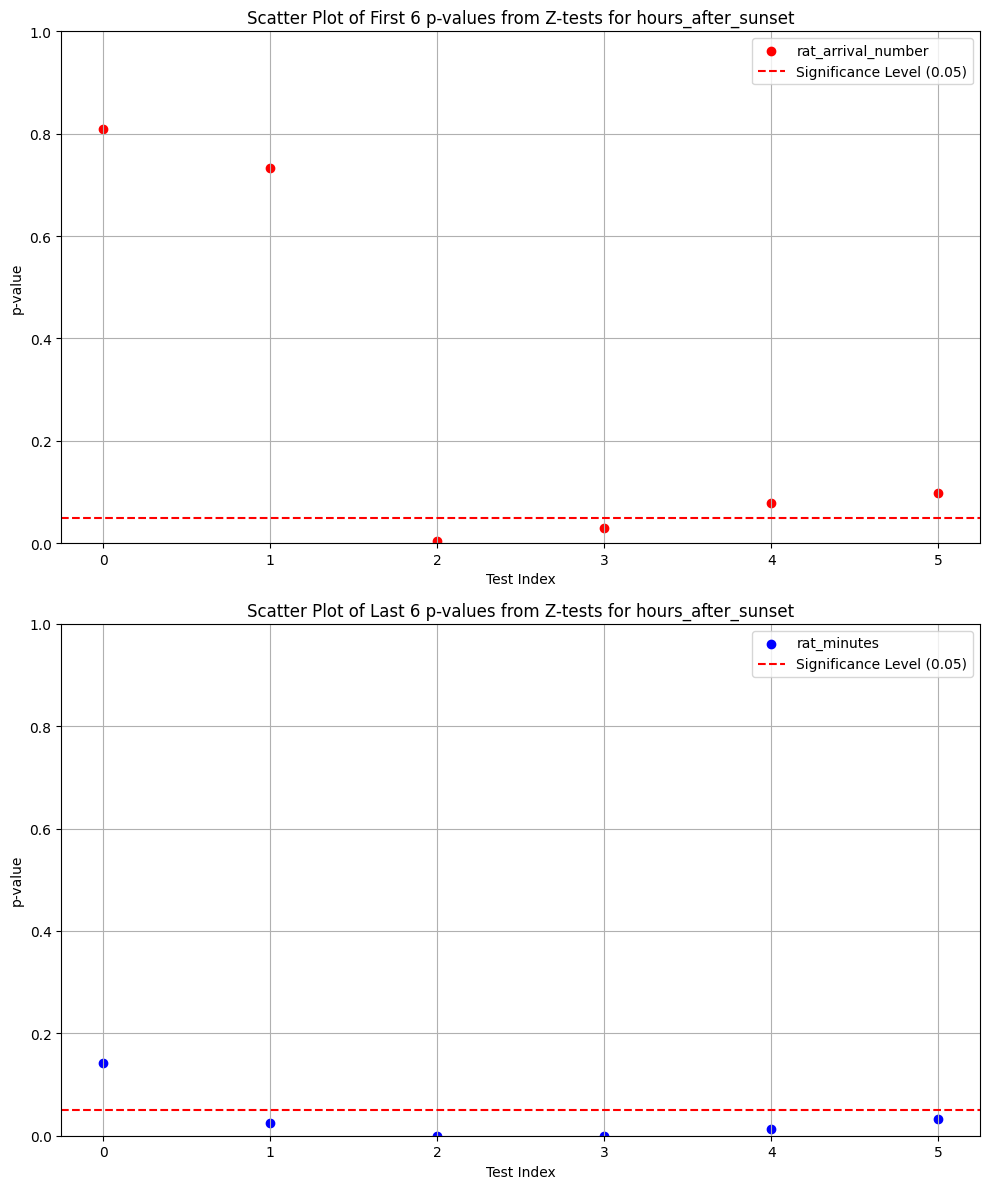

In [ ]:
dataframes = [df2_0, df2_1, df2_2, df2_3, df2_4, df2_5]
dataset_split_parameter = ['rat_arrival_number', 'rat_minutes']
test_column = ['hours_after_sunset']
               
               #, 'food_availability','hours_after_sunset']
# Loop through each DataFrame
# Loop through each DataFrame
# Initialize an empty list to store p-values
p_values = []

# Loop through each DataFrame
for df in dataframes:
    for x in dataset_split_parameter:
        for y in test_column:
            # Converts the x column to integers
            df[x] = df[x].astype(int)

            # Creates two dataframes as per the two sections
            df_above_zero = df[df[x] > 0]
            df_zero = df[df[x] == 0]

            # Perform Z-test if both groups have samples
            if len(df_above_zero) > 0 and len(df_zero) > 0:
                z_stats, p_val = ztest(df_above_zero[y], df_zero[y], alternative='two-sided')

                # Append the p-value to the list
                p_values.append(p_val)

                # Determine whether to accept or reject the null hypothesis
                conclusion = "We reject the null hypothesis." if p_val < 0.05 else "We accept the null hypothesis."


plt.figure(figsize=(10, 12))

# First subplot for the first 6 p-values
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(range(6), p_values[:6], color='red', marker='o', label='rat_arrival_number')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of First 6 p-values from Z-tests for hours_after_sunset')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Second subplot for the last 6 p-values
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.scatter(range(6), p_values[6:12], color='blue', marker='o', label='rat_minutes')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.title('Scatter Plot of Last 6 p-values from Z-tests for hours_after_sunset')
plt.xlabel('Test Index')
plt.ylabel('p-value')
plt.xticks(range(6))  # Set x-ticks to match the number of p-values
plt.ylim(0, 1)  # Set y-axis limits
plt.legend()
plt.grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()